# Execution Strategy Comparison — DA Positioning Signal

Holding entry signals fixed from notebook 01 (Section 4 best run, selected by **Calmar Ratio → Sharpe → Profit Factor → Return**), this notebook isolates the **execution layer** and answers a core trading question: *given an open DA position, which exit mechanism delivers the best risk-adjusted P&L?*

Four archetypes are tested across return, risk, and consistency dimensions:

| Strategy | Passive Fraction | Active Gate | Terminal Settlement |
|---|---|---|---|
| **Full Imbalance Exposure** | 0% | — | 100% rides to SSP/SBP imbalance |
| **Systematic Intraday Unwind** | 100% | — | 100% exits at intraday mid-market |
| **Conditional Intraday Liquidation** | 0% | TP/SL | MID on trigger; imbalance fallback |
| **Hybrid (50/50) Execution** | 50% | TP/SL | 50% passive MID + 50% active gate |

All four share identical signals. Every performance difference is attributable solely to the exit mechanism.

**Decision criterion applied throughout:** Calmar Ratio (primary) → Sharpe → Profit Factor → Total Return. The hedge ratio sensitivity sweep (Section 4) and decision framework (Section 6) use this same priority.

In [42]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.backtest.engine import run_backtest_from_dataframe

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

STARTING_CAPITAL = 50_000.0
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "da_positioning" / "s4_n5_t30_tc10"

In [ ]:
features = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
signals = pd.read_csv(ARTIFACT_DIR / "virtual" / "trading" / "signals.csv", parse_dates=["delivery_time"])

signals["delivery_time"] = pd.to_datetime(signals["delivery_time"], utc=True)

bt_df = features[["time", "day_ahead_price", "system_sell_price", "system_buy_price", "mid_price"]].copy()
bt_df = bt_df.merge(
    signals[["delivery_time", "signal", "predicted_spread"]].rename(columns={"delivery_time": "time"}),
    on="time",
    how="inner",
)

COMMON_KW = dict(
    signal_col="signal",
    da_price_col="day_ahead_price",
    sell_price_col="system_sell_price",
    buy_price_col="system_buy_price",
    time_col="time",
    starting_capital=STARTING_CAPITAL,
    cost_per_trade=1.00,
)

STRATEGIES = {
    "Full Imbalance Exposure":          dict(mid_price_col=None,        predicted_spread_col=None,              baseline_hedge_ratio=0.0),
    "Systematic Intraday Unwind":       dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=1.0),
    "Conditional Intraday Liquidation": dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.0),
    "Hybrid (50/50) Execution":         dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.5),
}

results = {}
for name, kw in STRATEGIES.items():
    df_out, metrics = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    results[name] = {"pnl": df_out[["time", "pnl"]], "metrics": metrics}

---
## 1. Virtual Trading Execution Comparison

All four strategies start from the same £50k capital and use identical entry signals. Differences in the curves are driven entirely by the exit mechanism — demonstrating the value (or cost) of each execution layer. Final account values are annotated at the end of each line.

In [ ]:
COLORS = {
    "Full Imbalance Exposure":          "#00b4d8",
    "Systematic Intraday Unwind":       "#e63946",
    "Conditional Intraday Liquidation": "#f4a261",
    "Hybrid (50/50) Execution":         "#2a9d8f",
}

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

for name, r in results.items():
    pnl_df = r["pnl"]
    equity = STARTING_CAPITAL + pnl_df["pnl"].cumsum()
    ax.plot(pnl_df["time"], equity, label=name, color=COLORS[name], linewidth=1.6)
    final_eq = equity.iloc[-1]
    ax.annotate(
        f"£{final_eq:,.0f}",
        xy=(pnl_df["time"].iloc[-1], final_eq),
        xytext=(8, 0),
        textcoords="offset points",
        color=COLORS[name],
        fontsize=9,
        fontweight="bold",
        va="center",
    )

ax.axhline(STARTING_CAPITAL, color="#444444", linestyle="--", linewidth=0.8)
ax.set_title("Virtual Trading Execution Comparison", fontsize=14, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Date", color="#999999", fontsize=10)
ax.set_ylabel("Account Equity", color="#999999", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.tick_params(colors="#999999")
for spine in ax.spines.values():
    spine.set_color("#333333")
ax.grid(True, alpha=0.12, color="#ffffff")
ax.legend(frameon=False, fontsize=9, labelcolor="white", loc="upper left")
fig.tight_layout()
plt.show()

---
## 2. Performance Tear Sheet

Side-by-side comparison of headline risk/return metrics across all four execution strategies. Total Return, Max Drawdown, and Sharpe Ratio are the key decision metrics. Margin Required is proxied at 1.5× the absolute max drawdown; ROCE (Return on Capital Employed) is Total PnL divided by this margin floor.

In [ ]:
rows = []
for name, r in results.items():
    m = r["metrics"]
    pnl_series = r["pnl"]["pnl"]

    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    n_trades = m.get("n_trades", int((pnl_series != 0).sum()))
    avg_trade = m["total_pnl"] / n_trades if n_trades > 0 else float("nan")
    margin_req = abs(m["max_drawdown"]) * 1.5
    roce = m["total_pnl"] / margin_req if margin_req > 0 else float("nan")

    rows.append({
        "Strategy":       name,
        "Total PnL":      f"£{m['total_pnl']:,.0f}",
        "Total Return":   f"{m['total_return_pct']:.1%}",
        "Sharpe":         f"{m['sharpe_ratio']:.3f}",
        "Calmar":         f"{calmar:.2f}",
        "Max Drawdown":   f"£{m['max_drawdown']:,.0f}",
        "Max DD %":       f"{max_dd_pct:.1%}",
        "Win Rate":       f"{m['win_rate']:.1%}",
        "Profit Factor":  f"{m['profit_factor']:.2f}",
        "N Trades":       f"{n_trades:,}",
        "Avg Trade (£)":  f"£{avg_trade:,.2f}",
        "Margin Req (£)": f"£{margin_req:,.0f}",
        "ROCE":           f"{roce:.1%}",
    })

tear_df = pd.DataFrame(rows).set_index("Strategy")
tear_df.style.set_properties(**{"text-align": "right"})

---
## 3. Risk vs. Reward — Efficient Frontier

Maximum Drawdown (X-axis, smaller to larger — lower risk on the left) plotted against Total PnL (Y-axis). Strategies in the upper-left quadrant offer higher return for lower drawdown — the efficient frontier of execution design.

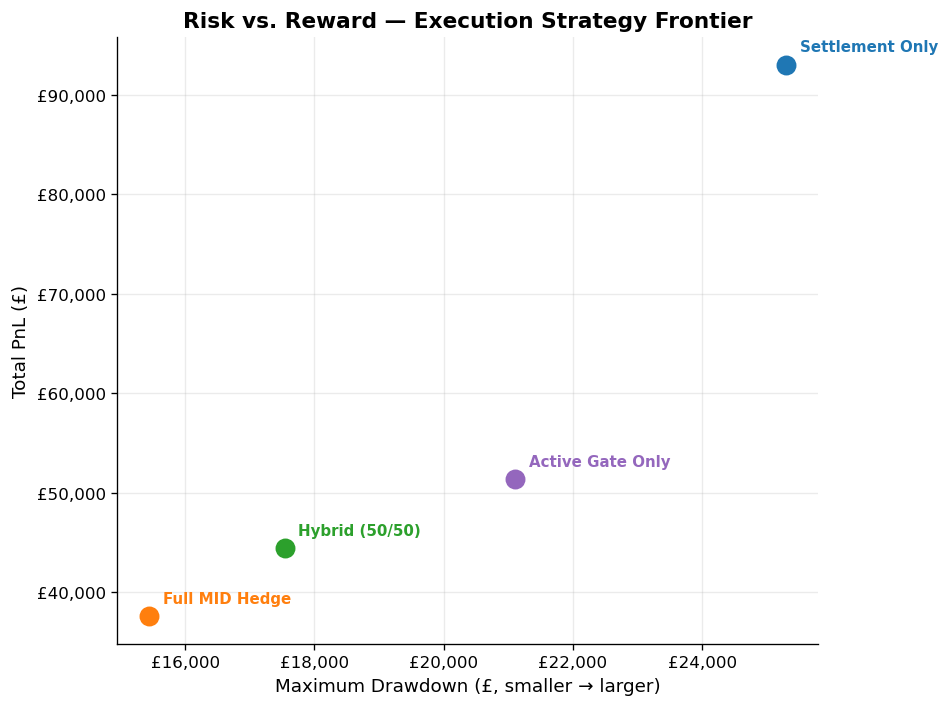

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    m = r["metrics"]
    dd = abs(m["max_drawdown"])
    pnl = m["total_pnl"]
    ax.scatter(dd, pnl, s=120, color=COLORS[name], zorder=5)
    ax.annotate(
        name, (dd, pnl),
        textcoords="offset points", xytext=(8, 8),
        fontsize=9, color=COLORS[name], fontweight="bold",
    )

ax.set_xlabel("Maximum Drawdown (£, smaller → larger)", fontsize=11)
ax.set_ylabel("Total PnL (£)", fontsize=11)
ax.set_title("Risk vs. Reward — Execution Strategy Frontier", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.show()

---
## 4. Hedge Ratio Sensitivity

How does the passive fraction (`baseline_hedge_ratio`) affect risk and return? This sweep holds all other parameters constant — identical signals, TC = £1.00/MWh, same TP/SL gate — and varies only the proportion allocated to passive MID exit.

A ratio of 0.0 routes all volume through the active TP/SL gate (imbalance as terminal fallback); 1.0 routes everything to passive MID with no active gate. Hybrid (50/50) Execution sits at 0.5, marked by the dashed line. The Calmar and Sharpe curves identify the optimal ratio for risk-adjusted return given this signal set.

In [ ]:
HEDGE_RATIOS = np.round(np.arange(0.0, 1.1, 0.1), 1)
sweep_records = []

for ratio in HEDGE_RATIOS:
    kw = dict(
        mid_price_col="mid_price",
        predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=ratio,
    )
    _, m = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    sweep_records.append({
        "ratio":     ratio,
        "total_pnl": m["total_pnl"],
        "sharpe":    m["sharpe_ratio"],
        "max_dd_pct": max_dd_pct,
        "calmar":    m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else np.nan,
    })

sweep_df = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, ylabel, formatter) in zip(axes, [
    ("total_pnl",  "Total PnL (£)",      lambda x, _: f"£{x:,.0f}"),
    ("sharpe",     "Sharpe Ratio",        None),
    ("max_dd_pct", "Max Drawdown (%)",    lambda x, _: f"{x:.0%}"),
]):
    ax.plot(sweep_df["ratio"], sweep_df[col], marker="o", linewidth=2, color="#2a9d8f")
    ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Hybrid (50/50) Execution")
    ax.set_xlabel("Passive Hedge Ratio")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.set_xticks(HEDGE_RATIOS)
    if formatter:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    ax.legend(frameon=False, fontsize=8)

plt.suptitle("Hedge Ratio Sensitivity — Passive Fraction 0 → 1", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Top 5 Worst Drawdowns — Full Imbalance Exposure

The deepest drawdown episodes for the Full Imbalance Exposure strategy highlight the tail-risk dates where unhedged settlement exposure produced the largest peak-to-trough equity declines. These are the periods that define the margin requirement floor.

In [ ]:
_dd = results["Full Imbalance Exposure"]["pnl"].copy()
_dd["equity"] = STARTING_CAPITAL + _dd["pnl"].cumsum()
_dd["peak"] = _dd["equity"].cummax()
_dd["drawdown"] = _dd["equity"] - _dd["peak"]

_dd["in_dd"] = _dd["drawdown"] < 0
_dd["dd_group"] = (_dd["in_dd"] != _dd["in_dd"].shift()).cumsum()

_worst = []
for _, grp in _dd[_dd["in_dd"]].groupby("dd_group"):
    trough_idx = grp["drawdown"].idxmin()
    t = grp.loc[trough_idx]
    _worst.append({
        "Trough Date": t["time"],
        "Depth (£)": t["drawdown"],
        "_raw": t["drawdown"],
        "Depth (%)": t["drawdown"] / t["peak"],
        "Peak Equity": t["peak"],
        "Trough Equity": t["equity"],
        "Duration (SP)": len(grp),
    })

dd_table = (
    pd.DataFrame(_worst)
    .sort_values("_raw")
    .head(5)
    .reset_index(drop=True)
)
dd_table.index = dd_table.index + 1
dd_table.index.name = "Rank"

dd_display = dd_table.drop(columns=["_raw"]).copy()
dd_display["Trough Date"] = pd.to_datetime(dd_display["Trough Date"]).dt.strftime("%Y-%m-%d %H:%M")
dd_display["Depth (£)"] = dd_table["Depth (£)"].map(lambda x: f"£{x:,.0f}")
dd_display["Depth (%)"] = dd_table["Depth (%)"].map(lambda x: f"{x:.1%}")
dd_display["Peak Equity"] = dd_table["Peak Equity"].map(lambda x: f"£{x:,.0f}")
dd_display["Trough Equity"] = dd_table["Trough Equity"].map(lambda x: f"£{x:,.0f}")
dd_display.style.set_properties(**{"text-align": "right"})

---
## 6. Decision Framework

Quantified trade-offs between strategies, computed directly from backtest results. The key question is whether the reduction in drawdown that Hybrid (50/50) Execution buys over Full Imbalance Exposure is worth the sacrifice in absolute return — and whether that calculus changes as account size grows.

In [ ]:
framework_rows = []
for name, r in results.items():
    m = r["metrics"]
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    framework_rows.append({
        "Strategy": name,
        "Return": f"{m['total_return_pct']:+.1%}",
        "Sharpe": f"{m['sharpe_ratio']:.3f}",
        "Calmar": f"{calmar:.2f}",
        "Max DD (£)": f"£{m['max_drawdown']:,.0f}",
        "Max DD (%)": f"{max_dd_pct:.1%}",
        "Win Rate": f"{m['win_rate']:.1%}",
        "Profit Factor": f"{m['profit_factor']:.2f}",
    })

fw_df = pd.DataFrame(framework_rows).set_index("Strategy")

fie_m = results["Full Imbalance Exposure"]["metrics"]
hyb_m = results["Hybrid (50/50) Execution"]["metrics"]
fie_dd = abs(fie_m["max_drawdown"]) / STARTING_CAPITAL
hyb_dd = abs(hyb_m["max_drawdown"]) / STARTING_CAPITAL
dd_reduction = (fie_dd - hyb_dd) / fie_dd
pnl_sacrifice = (fie_m["total_pnl"] - hyb_m["total_pnl"]) / fie_m["total_pnl"]

tradeoff = pd.DataFrame([{
    "DD Reduction": f"{dd_reduction:.0%}",
    "Return Sacrificed": f"{pnl_sacrifice:.0%}",
}], index=[f"Full Imbalance Exposure → Hybrid (50/50) Execution (£{STARTING_CAPITAL:,.0f} account)"])
tradeoff.index.name = "Transition"

display(fw_df.style.set_properties(**{"text-align": "right"}))
display(tradeoff.style.set_properties(**{"text-align": "right"}))

---
*Exit mechanism drives as much P&L dispersion as signal quality. Calibrate `baseline_hedge_ratio` against drawdown tolerance first — return differential can be recaptured by scaling position size as account equity grows.*